# Data Exploration: CoNLL-2003 & CrossNER Politics

This notebook explores the source domain (CoNLL-2003) and target domain (CrossNER Politics) datasets,
analyses label distributions and sentence statistics, and documents the hierarchy mapping between label sets.

In [13]:
import os
import subprocess
import shutil
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from datasets import load_dataset


DATA_RAW = Path('../data/raw')
CONLL_DIR = DATA_RAW / 'conll2003'
POLITICS_DIR = DATA_RAW / 'crossner' / 'politics'

---
## 1. Load Datasets

In [ ]:
conll = load_dataset('conll2003')

# CoNLL-2003 NER tag mapping (index --> label)
CONLL_ID2LABEL = conll['train'].features['ner_tags'].feature.names
print('CoNLL-2003 NER labels:', CONLL_ID2LABEL)
print()
for split in ['train', 'validation', 'test']:
    n_sent = len(conll[split])
    n_tok  = sum(len(s['tokens']) for s in conll[split])
    print(f'  {split:>10}: {n_sent:,} sentences  |  {n_tok:,} tokens')

CoNLL-2003 NER labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

       train: 14,041 sentences  |  203,621 tokens
  validation: 3,250 sentences  |  51,362 tokens
        test: 3,453 sentences  |  46,435 tokens


In [15]:
CROSSNER_REPO = 'https://github.com/zhouxiangru/CrossNER'
CLONE_DIR = Path('../data/raw/_crossner_repo')

if not POLITICS_DIR.exists() or not any(POLITICS_DIR.iterdir()):
    POLITICS_DIR.mkdir(parents=True, exist_ok=True)
    if not CLONE_DIR.exists():
        print('Cloning CrossNER repository...')
        subprocess.run(['git', 'clone', '--depth', '1', CROSSNER_REPO, str(CLONE_DIR)], check=True)
    src = CLONE_DIR / 'data' / 'politics'
    for f in src.iterdir():
        shutil.copy(f, POLITICS_DIR / f.name)
    print('Copied politics splits to', POLITICS_DIR)
else:
    print('Politics data already present:', list(POLITICS_DIR.iterdir()))

Politics data already present: [WindowsPath('../data/raw/crossner/politics/dev.txt'), WindowsPath('../data/raw/crossner/politics/test.txt'), WindowsPath('../data/raw/crossner/politics/train.txt')]


In [16]:
def parse_conll_iob(path):
    """Parse a CoNLL-style IOB2 file. Returns list of (tokens, tags) tuples."""
    sentences, tokens, tags = [], [], []
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            line = line.rstrip()
            if not line or line.startswith('-DOCSTART-'):
                if tokens:
                    sentences.append((tokens, tags))
                    tokens, tags = [], []
            else:
                parts = line.split()
                tokens.append(parts[0])
                tags.append(parts[-1])
    if tokens:
        sentences.append((tokens, tags))
    return sentences

# CrossNER Politics uses train.txt / dev.txt / test.txt
pol_splits = {}
for fname, key in [('train.txt', 'train'), ('dev.txt', 'validation'), ('test.txt', 'test')]:
    p = POLITICS_DIR / fname
    pol_splits[key] = parse_conll_iob(p)

for split, data in pol_splits.items():
    n_tok = sum(len(t) for t, _ in data)
    print(f'  {split:>10}: {len(data):,} sentences  |  {n_tok:,} tokens')

       train: 200 sentences  |  8,384 tokens
  validation: 541 sentences  |  24,624 tokens
        test: 651 sentences  |  27,585 tokens


---
## CoNLL-2003 Analysis

### Label Distribution

             train  validation  test
Entity Type                         
ORG           6321        1341  1661
MISC          3438         922   702
PER           6600        1842  1617
LOC           7140        1837  1668


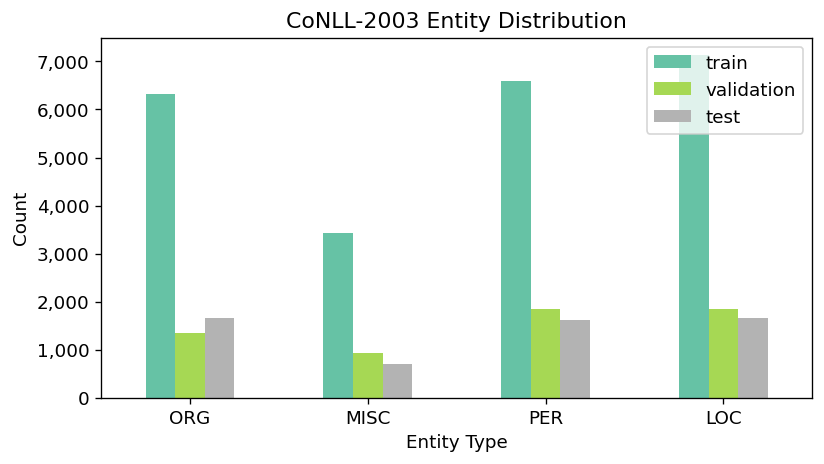

In [17]:
def conll_entity_counts(dataset_split, id2label):
    """Count entity spans (B- tags only) per coarse type."""
    counts = Counter()
    for row in dataset_split:
        for tag_id in row['ner_tags']:
            label = id2label[tag_id]
            if label.startswith('B-'):
                counts[label[2:]] += 1
    return counts

conll_counts = {split: conll_entity_counts(conll[split], CONLL_ID2LABEL)
                for split in ['train', 'validation', 'test']}

conll_df = pd.DataFrame(conll_counts).fillna(0).astype(int)
conll_df.index.name = 'Entity Type'
print(conll_df)

ax = conll_df.plot(kind='bar', figsize=(7, 4), rot=0, colormap='Set2')
ax.set_title('CoNLL-2003 Entity Distribution')
ax.set_xlabel('Entity Type')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### Sentence Length Statistics

In [18]:
for split in ['train', 'validation', 'test']:
    lengths = [len(s['tokens']) for s in conll[split]]
    print(f'{split:>10}  mean={np.mean(lengths):.1f}  median={np.median(lengths):.0f}  '
          f'min={min(lengths)}  max={max(lengths)}')

     train  mean=14.5  median=10  min=1  max=113
validation  mean=15.8  median=11  min=1  max=109
      test  mean=13.4  median=9  min=1  max=124


### Token Count per Entity Type (train)

In [19]:
def conll_token_counts(dataset_split, id2label):
    """Count tokens belonging to each entity type (B- and I- combined)."""
    counts = Counter()
    for row in dataset_split:
        for tag_id in row['ner_tags']:
            label = id2label[tag_id]
            if label != 'O':
                counts[label[2:]] += 1
    return counts

print('Token counts per entity type (train):')
print(pd.Series(conll_token_counts(conll['train'], CONLL_ID2LABEL)).sort_values(ascending=False).to_string())

Token counts per entity type (train):
PER     11128
ORG     10025
LOC      8297
MISC     4593


---
## CrossNER Politics Analysis

### Label Distribution

In [ ]:
POLITICS_TYPES = [
    'person', 'politician', 'organisation', 'politicalparty',
    'location', 'country', 'misc', 'event', 'election'
]

def politics_entity_counts(sentences):
    counts = Counter()
    for _, tags in sentences:
        for tag in tags:
            if tag.startswith('B-'):
                counts[tag[2:].lower()] += 1
    return counts

pol_counts = {split: politics_entity_counts(data) for split, data in pol_splits.items()}

pol_df = pd.DataFrame(pol_counts, index=POLITICS_TYPES).fillna(0).astype(int)
pol_df.index.name = 'Entity Type'
print(pol_df)

ax = pol_df.plot(kind='bar', figsize=(10, 4), rot=30, colormap='Set2')
ax.set_title('CrossNER Politics Entity Distribution')
ax.set_xlabel('Entity Type')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### Sentence Length Statistics

In [ ]:
for split, data in pol_splits.items():
    lengths = [len(t) for t, _ in data]
    print(f'{split:>10}  mean={np.mean(lengths):.1f}  median={np.median(lengths):.0f}  '
          f'min={min(lengths)}  max={max(lengths)}')

### Token Count per Entity Type (train)

In [22]:
def politics_token_counts(sentences):
    counts = Counter()
    for _, tags in sentences:
        for tag in tags:
            if tag != 'O':
                counts[tag[2:].lower()] += 1
    return counts

print('Token counts per entity type (train):')
print(pd.Series(politics_token_counts(pol_splits['train'])).sort_values(ascending=False).to_string())

Token counts per entity type (train):
politician        700
election          590
politicalparty    554
organisation      411
location          393
misc              123
country            70
event              69
person             19


---
## Hierarchy Mapping

CrossNER Politics introduces fine-grained entity types that are specialisations of the four CoNLL-2003 coarse types.
The table below documents this mapping. **Bold** types are fine-grained specialisations that do not exist in CoNLL-2003
and are therefore harder for a model trained only on CoNLL-2003 to recognise.

| CoNLL-2003 | CrossNER Politics |
|:---:|:---|
| PER  | person, **politician** |
| ORG  | organisation, **politicalparty** |
| LOC  | location, **country** |
| MISC | misc, **event**, **election** |

### Observations

- **`politician`** and **`political-party`** are frequent in CrossNER Politics yet have *zero* explicit CoNLL-2003 training examples — a model must generalise from `PER`/`ORG` representations.
- **`country`** is a geographic sub-type of `LOC`; while CoNLL-2003 contains many `LOC` entities, country names in a political context may carry different distributional properties.
- **`event`** and **`election`** fall under the sparse `MISC` CoNLL-2003 class, which is already the least represented type — making these the hardest transfer targets.
- Overall, the CrossNER Politics label set is richer and more domain-specific, so a naive zero-shot transfer from CoNLL-2003 is expected to underperform on fine-grained types relative to the coarse ones.